**Table of contents**<a id='toc0_'></a>

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import time
from collections import namedtuple

import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst
from consav.linear_interp import interp_1d, interp_1d_vec
from consav.golden_section_search import optimizer

# The endogenous grid method

This notebook solves the same infinite-horizon household problem as the previous one, but with the endogenous
grid method (EGM) of Carroll instead of value function iteration.

The function we end up with, `solve_hh_backwards`, is the one we use for the rest of the course. It comes back
almost line for line in `04-Stationary-Equilibrium/0_HANC/household_problem.py`.

## Why not VFI?

The standard method to solve the household problem is VFI: guess a value function $v(z_t,a_{t-1})$ and iterate on
the right-hand side of the Bellman equation,
$v^{n+1}(z_t,a_{t-1}) = \max_{c_t}\{u(c_t)+\beta\mathbb{E}_t[v^{n}(z_{t+1},a_t)]\}$, until $v^{n+1} \approx v^{n}$.

The issue with this method is that for each point $(z_t,a_{t-1})$ on our grids we need to run an optimization
algorithm, like the golden section search of the previous notebook, and that is costly. It is also not very
accurate, as we saw with the MPC.

The endogenous grid method proposes to iterate on the Euler-equation instead.

## The model

$$
\begin{aligned}
v(z_t,a_{t-1}) &= \max_{c_t} \frac{c_t^{1-\sigma}}{1-\sigma} + \beta \mathbb{E}_t\left[v(z_{t+1},a_t)\right] \\
&\text{s.t.} \\
a_t &= (1+r)a_{t-1} + wz_t - c_t \geq 0 \\
\log z_{t+1} &= \rho_z \log z_t + \psi_{t+1}, \qquad \psi_{t+1}\sim\mathcal{N}(0,\sigma_\psi^2), \qquad \mathbb{E}[z_t]=1
\end{aligned}
$$

Exactly the model of the previous notebook. Only the solution method changes.

One implementation detail: we want the solver to be `numba`-compiled, and `numba` cannot take an ordinary Python
class. We therefore hold the parameters in a `namedtuple`, whose attributes it does understand. In lecture 04 the
same job is done by `EconModelClass` together with `jit`.

In [2]:
Parameters = namedtuple('Parameters',
    'beta sigma r w rho_z sigma_psi Nz Na a_min a_max a_grid z_grid z_trans z_ergodic')

def setup():
    """ baseline parameters """

    # preferences
    beta = 0.96
    sigma = 2.0

    # prices
    r = 0.02
    w = 1.0

    # income
    rho_z = 0.95
    sigma_psi = 0.10
    Nz = 7
    z_grid,z_trans,z_ergodic,_,_ = log_rouwenhorst(rho_z,sigma_psi,Nz)

    # grids
    Na = 300
    a_min = 0.0
    a_max = 100.0
    a_grid = equilogspace(a_min,a_max,Na)

    return Parameters(beta,sigma,r,w,rho_z,sigma_psi,Nz,Na,a_min,a_max,a_grid,z_grid,z_trans,z_ergodic)

par = setup()

In [3]:
print('z_grid    =',np.round(par.z_grid,4))
print('z_ergodic =',np.round(par.z_ergodic,4))
print('mean of z =',np.sum(par.z_grid*par.z_ergodic))

z_grid    = [0.4336 0.5632 0.7315 0.9501 1.2341 1.6029 2.082 ]
z_ergodic = [0.0156 0.0938 0.2344 0.3125 0.2344 0.0937 0.0156]
mean of z = 0.9999999999999998


## The EGM algorithm, step by step

Our goal is to obtain the policy functions $a^{\ast}(z_t,a_{t-1})$ and $c^{\ast}(z_t,a_{t-1})$ for each point on the grids `a_grid`
and `z_grid`.

Recall that the first-order condition of the problem writes $u'(c_t)=\beta \underline{v}_a(z_t,a_t)$ where
$\underline{v}(z_t,a_t) = \mathbb{E}_t[v(z_{t+1},a_t)]$ is the beginning-of-period value function from the last notebook.
Our first step is thus to define an initial guess for $\underline{v}_a$.

In [4]:
c = par.r*par.a_grid[np.newaxis,:] + par.w*par.z_grid[:,np.newaxis] # implied guess of a(z,a_) = a_
v_a = (1+par.r)*c**(-par.sigma) # envelope condition, given our guess on the policy function
vbeg_a = par.z_trans@v_a # take the expectation with a matrix multiplication

Instead of fixing a grid over the state $a_{t-1}$, we now set a grid over the choice $a_t$. We can then use the first-order condition
to obtain $c_t$ as a function of $a_t$,

$$
c(z_t,a_t) = u'^{-1}\left[\beta \underline{v}_a(z_t,a_t)\right] = \left(\beta \underline{v}_a(z_t,a_t)\right)^{-1/\sigma}
$$

In [5]:
c_endo = (par.beta*vbeg_a)**(-1/par.sigma) # invert the FOC to get c(z,a)

print('c_endo.shape =',c_endo.shape)

c_endo.shape = (7, 300)


We also know that, from the budget constraint,

$$
a_t + c(z_t,a_t) = (1+r)a_{t-1} + wz_t
$$

Note that in this equation $a_t$ and $z_t$ are defined on their grids, and we now know $c(z_t,a_t)$. We can thus invert
it to obtain

$$
a_{t-1}(z_t,a_t) = \frac{a_t + c(z_t,a_t) - wz_t}{1+r}
$$

where $a_{t-1}(z_t,a_t)$ is the *endogenous grid* for assets, hence the name of the method.

We are reversing the problem: instead of finding the optimal $a_t$ given the state $(z_t,a_{t-1})$, we are asking
which $a_{t-1}$ today would make it optimal to choose $a_t$, given the Euler-equation.

Of course, we are eventually interested in $a^{\ast}(z_t,a_{t-1})$ on the *exogenous* grid. To get there we interpolate
the function $a_t(z_t,a_{t-1}^{\text{endo}})$ at the points `a_grid`. Note that `interp_1d_vec` writes its result into the
array we pass last, rather than returning it.

In [6]:
a = np.zeros((par.Nz,par.Na))

for i_z in range(par.Nz):

    # a. endogenous grid from the budget constraint
    a_endo = (c_endo[i_z] + par.a_grid - par.w*par.z_grid[i_z])/(1+par.r)

    # b. interpolate a(z,a_endo) at the points a_grid, which gives a(z,a_)
    interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_z])

The last thing to note is that, because of the borrowing constraint, some of the $a^{\ast}(z_t,a_{t-1})$ implied by the
first-order condition are not feasible. We simply impose the constraint by setting them to zero.

In [7]:
a = np.fmax(a,0.0) # enforce the borrowing constraint

We can then compute $c^{\ast}(z_t,a_{t-1})$ as the residual of the budget constraint, use the envelope condition to
update our guess of the derivative of the value function,

$$
v_a(z_t,a_{t-1}) = (1+r)c^{\ast}(z_t,a_{t-1})^{-\sigma}
$$

and take the expectation with the transition matrix.

In [8]:
for i_z in range(par.Nz):
    c[i_z] = par.a_grid*(1+par.r) + par.w*par.z_grid[i_z] - a[i_z] # consumption from the budget constraint

v_a = (1+par.r)*c**(-par.sigma) # envelope condition
vbeg_a_new = par.z_trans@v_a # expectation step

## Putting it in a function

We then put all of this in one function and iterate until convergence.

Algorithm:
Guess a function $\underline{v}_a(z_t,a_t)$. Then
1. Back out the implied consumption, $c(z_t,a_t) = u'^{-1}\left[\beta\underline{v}_a(z_t,a_t)\right]$
2. Get an *endogenous grid* for assets from the budget constraint, $a_{t-1}(z_t,a_t)=\frac{a_t+c(z_t,a_t)-wz_t}{1+r}$
3. This gives $a^{\ast}(z_t,a_{t-1})$ on the endogenous grid. Put it back on the exogenous grid by interpolation
4. Impose the borrowing constraint by setting $a^{\ast}(z_t,a_{t-1})<0$ to zero
5. Back out consumption from the budget constraint, $c^{\ast}(z_t,a_{t-1})=(1+r)a_{t-1}+wz_t-a^{\ast}(z_t,a_{t-1})$
6. Update the guess with the envelope condition, $\underline{v}_a(z_t,a_t) = \mathbb{E}_t\left[(1+r)u'(c^{\ast}(z_{t+1},a_t))\right]$, one product with $\Pi_z$

Iterate until convergence.

Two things about the implementation. The loop over productivity states runs in parallel with `nb.prange`, since
the states do not talk to each other within a step. And the outputs `vbeg_a`, `a` and `c` are written *into*
arrays we pass in, rather than returned: allocating fresh arrays on every one of a few hundred iterations would
be wasteful, and this is the convention `GEModelTools` expects.

In [9]:
@nb.njit(parallel=True)
def solve_hh_backwards(par,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c):
    """ solve backwards with vbeg_a from previous iteration (here vbeg_a_plus) """

    # a. solve step
    for i_z in nb.prange(par.Nz):

        # i. back out consumption from Va
        c_endo = (par.beta*vbeg_a_plus[i_z])**(-1/par.sigma)

        # ii. compute endogenous grid of assets
        a_endo = (c_endo + par.a_grid - w*par.z_grid[i_z])/(1+r)

        # iii. interpolation to fixed grid
        interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_z])

        # iv. impose borrowing constraint
        a[i_z,:] = np.fmax(a[i_z,:],0.0) # enforce borrowing constraint

        # v. back out consumption
        c[i_z] = par.a_grid*(1+r) + w*par.z_grid[i_z] - a[i_z]

    # b. expectation step
    v_a = (1+r)*c**(-par.sigma) # envelope condition
    vbeg_a[:] = z_trans@v_a # expectation step

Then, for a given $r$ and $w$, we loop over this step until the `vbeg_a_plus` we feed into the function is
arbitrarily close to the `vbeg_a` that it writes out.

In [10]:
def solve_hh_ss(par,r,w,max_iter=10_000,tol=1e-10):
    """ solve the household problem in the infinite horizon """

    # a. allocate
    vbeg_a = np.zeros((par.Nz,par.Na))
    a = np.zeros((par.Nz,par.Na))
    c = np.zeros((par.Nz,par.Na))

    # b. initial guess: a(z,a_) = a_, so consumption is the annuity value
    c_guess = r*par.a_grid[np.newaxis,:] + w*par.z_grid[:,np.newaxis]
    vbeg_a_plus = par.z_trans@((1+r)*c_guess**(-par.sigma))

    errors = []

    # c. iterate
    for it in range(max_iter):

        solve_hh_backwards(par,par.z_trans,r,w,vbeg_a_plus,vbeg_a,a,c)

        error = np.max(np.abs(vbeg_a-vbeg_a_plus))
        errors.append(error)
        if error < tol: break

        vbeg_a_plus[:] = vbeg_a

    return c,a,vbeg_a,errors

In [11]:
t0 = time.time()
c,a,vbeg_a,errors = solve_hh_ss(par,par.r,par.w)

print(f'converged in {len(errors)} iterations and {time.time()-t0:.2f} seconds')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


converged in 280 iterations and 3.40 seconds


That's it. We have the policy functions of the households, for given $r$ and $w$, that is, in partial
equilibrium.

Do not read too much into that timing: nearly all of it is `numba` compiling `solve_hh_backwards` on its first
call. The next section measures what a backward step actually costs once it is compiled.

In lecture 04 the same function carries one extra leading dimension on `a`, `c` and `vbeg_a`, for households
that differ in some fixed characteristic such as the discount factor. That is why the code there is indexed
`a[0,i_z]` rather than `a[i_z]`. Nothing else changes.

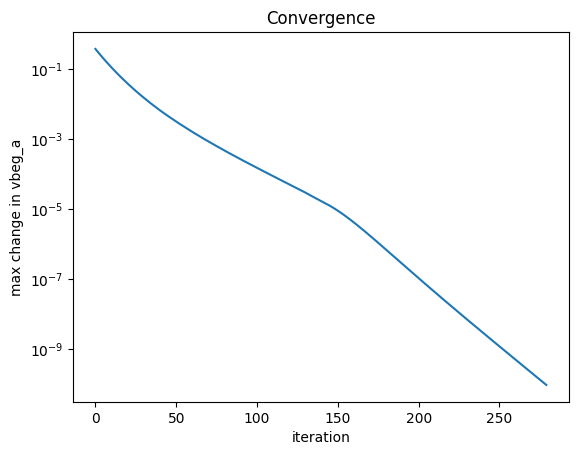

In [12]:
plt.plot(errors)
plt.yscale('log')
plt.title('Convergence')
plt.xlabel('iteration')
plt.ylabel('max change in vbeg_a')
plt.savefig('figs/egm_convergence.pdf')
plt.show()

The error falls at a constant rate on a log scale. That rate is the contraction modulus: each backward step
shrinks the distance to the fixed point by roughly a factor $\beta$, which is exactly what the contraction
mapping theorem promises.

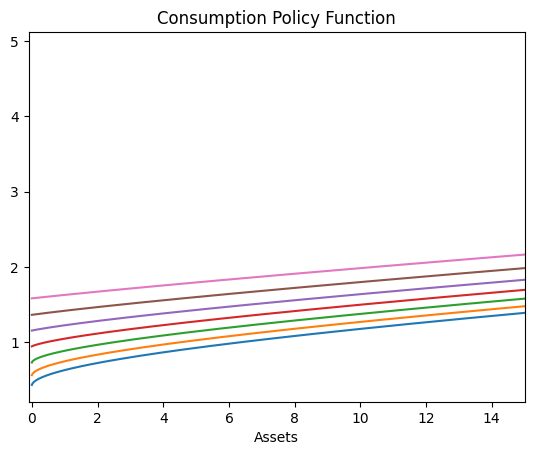

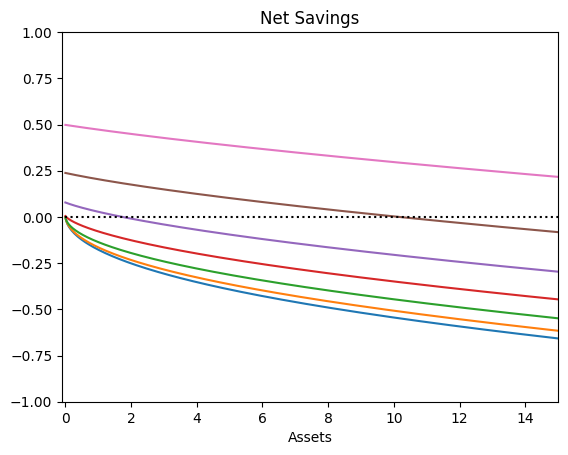

In [13]:
plt.plot(par.a_grid,c.T)
plt.xlim(-0.1,15)
plt.title('Consumption Policy Function')
plt.xlabel('Assets')
plt.savefig('figs/egm_c_func.pdf')
plt.show()

plt.plot(par.a_grid,(a-par.a_grid[np.newaxis,:]).T)
plt.plot(par.a_grid,np.zeros_like(par.a_grid),linestyle=':',color='black')
plt.xlim(-0.1,15)
plt.ylim(-1,1)
plt.title('Net Savings')
plt.xlabel('Assets')
plt.savefig('figs/egm_a_func.pdf')
plt.show()

As expected, the consumption function is a concave function of wealth, and net savings are a decreasing
function of wealth which crosses the zero line, implying buffer-stock behavior.

### How fast is it?

The compilation happens once, so what matters for the equilibrium solver of lecture 04, which calls this
function thousands of times, is the cost of a step after that.

In [14]:
vbeg_a_plus = vbeg_a.copy()

t0 = time.time()
for _ in range(100):
    solve_hh_backwards(par,par.z_trans,par.r,par.w,vbeg_a_plus,vbeg_a,a,c)

print(f'{(time.time()-t0)/100*1000:.3f} ms per EGM backward step')

0.106 ms per EGM backward step


The previous notebook needed 339 VFI iterations to solve the same model, each one running a golden section
search at every one of the $\#_z \times \#_a$ grid points. Here a backward step is a handful of vectorized
operations and one interpolation per productivity state, with no optimizer at all.

## Is it right?

EGM is fast, but is it *accurate*? Go back to the deterministic 3-period problem of notebook 02, where we know
the exact answer, and compare the two methods on it.

In [15]:
ParametersPIH = namedtuple('ParametersPIH','beta sigma r y T Na a_min a_max a_grid')

def setup_pih(Na=200):
    """ the deterministic 3-period problem of notebook 02 """

    a_min,a_max = 0.0,5.0

    return ParametersPIH(0.99,2.0,0.02,np.array([1.5,1.0,0.5]),3,Na,a_min,a_max,
        equilogspace(a_min,a_max,Na))

par_pih = setup_pih()

R = 1+par_pih.r
kappa = (par_pih.beta*R)**(1/par_pih.sigma)/R
MPC = (1-kappa)/(1-kappa**par_pih.T)
h0 = np.sum(par_pih.y/R**np.arange(par_pih.T))

In [16]:
@nb.njit
def value_of_choice(c,m,beta,sigma,a_grid,v_plus):
    """ negative of the value of consuming c out of cash-on-hand m """

    return -(c**(1-sigma)/(1-sigma) + beta*interp_1d(a_grid,v_plus,m-c))

@nb.njit
def solve_vfi_pih(par,c,v):
    """ solve the deterministic 3-period problem backwards with VFI """

    for t in range(par.T-1,-1,-1):
        for i_a_lag in range(par.Na):

            # i. cash-on-hand
            m = (1+par.r)*par.a_grid[i_a_lag] + par.y[t]

            # ii. consume everything in the last period, otherwise optimize
            if t == par.T-1:
                c[t,i_a_lag] = m
            else:
                c[t,i_a_lag] = optimizer(value_of_choice,1e-8,m-par.a_min,
                    args=(m,par.beta,par.sigma,par.a_grid,v[t+1]),tol=1e-10)

            # iii. value
            v[t,i_a_lag] = c[t,i_a_lag]**(1-par.sigma)/(1-par.sigma)
            if t < par.T-1:
                v[t,i_a_lag] += par.beta*interp_1d(par.a_grid,v[t+1],m-c[t,i_a_lag])

In [17]:
@nb.njit
def solve_egm_pih(par,c):
    """ solve the deterministic 3-period problem backwards with EGM """

    for t in range(par.T-1,-1,-1):

        if t == par.T-1:

            c[t] = (1+par.r)*par.a_grid + par.y[t]

        else:

            # i. back out consumption from the Euler-equation
            c_endo = (par.beta*(1+par.r)*c[t+1]**(-par.sigma))**(-1/par.sigma)

            # ii. endogenous grid of cash-on-hand
            m_endo = par.a_grid + c_endo

            # iii. interpolation to fixed grid, constrained households separately
            for i_a_lag in range(par.Na):
                m = (1+par.r)*par.a_grid[i_a_lag] + par.y[t]
                if m <= m_endo[0]:
                    c[t,i_a_lag] = m - par.a_min
                else:
                    c[t,i_a_lag] = interp_1d(m_endo,c_endo,m)

In [18]:
print('   Na    VFI max rel. error    EGM max rel. error')
for Na in [25,50,100,200,400]:

    par_ = setup_pih(Na)
    c_closed = MPC*(R*par_.a_grid + h0)

    c_vfi = np.zeros((par_.T,Na))
    solve_vfi_pih(par_,c_vfi,np.zeros((par_.T,Na)))

    c_egm = np.zeros((par_.T,Na))
    solve_egm_pih(par_,c_egm)

    err_vfi = np.max(np.abs(c_vfi[0]/c_closed-1))
    err_egm = np.max(np.abs(c_egm[0]/c_closed-1))

    print(f'{Na:5d}         {err_vfi:.2e}             {err_egm:.2e}')

   Na    VFI max rel. error    EGM max rel. error


   25         2.58e-02             6.66e-16
   50         1.40e-02             6.66e-16
  100         7.61e-03             6.66e-16
  200         3.55e-03             8.88e-16
  400         1.95e-03             8.88e-16


EGM is exact to machine precision with 25 grid points, where VFI needs hundreds for three digits.

Be careful about *why*, though. Without risk and away from the constraint, the consumption function is exactly
linear in cash-on-hand, and linear interpolation of a linear function is exact. That part is special to this
problem.

But the general point survives. EGM interpolates the *policy* function while VFI interpolates the *value*
function, and the policy function is much closer to a straight line. This is also why the MPC calculation that
came out ragged in the previous notebook is clean here.

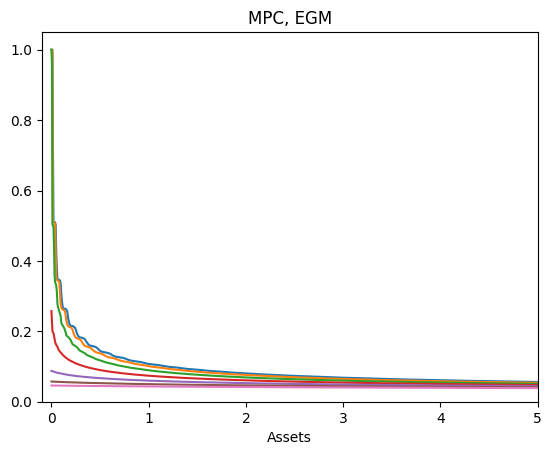

negative MPCs: 0 (there were 30 with VFI)


In [19]:
MPC_egm = np.zeros((par.Nz,par.Na))
MPC_egm[:,:-1] = (c[:,1:]-c[:,:-1])/((1+par.r)*(par.a_grid[1:]-par.a_grid[:-1]))
MPC_egm[:,-1] = MPC_egm[:,-2]

plt.plot(par.a_grid,MPC_egm.T)
plt.xlim(-0.1,5)
plt.ylim(0,1.05)
plt.title('MPC, EGM')
plt.xlabel('Assets')
plt.savefig('figs/egm_MPC.pdf')
plt.show()

print(f'negative MPCs: {np.sum(MPC_egm < 0)} (there were 30 with VFI)')